# Figure 3: deBoer MPRA performance


### Make predictions


In [ ]:
import torch
from yeastbench.deboer import PromoterDataset
from torch.utils.data import DataLoader
from yorzoi.utils import untransform_then_unbin
from yorzoi.model.borzoi import Borzoi

test_dataset = PromoterDataset()
test_loader = DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    prefetch_factor=4,
    persistent_workers=True,
)

DEVICE = "cuda:0"

model = Borzoi.from_pretrained("tom-ellis-lab/yorzoi")
model = model.to(DEVICE)
model.eval()

predictions = []

with torch.no_grad(), torch.amp.autocast("cuda"):
    for b_idx, (seqs, exp_val) in enumerate(test_loader):
        L = seqs.shape[1]  # expects (B, L, 4)
        L2 = (L // 32) * 32  # nearest lower multiple of 32
        trim = L - L2
        left = trim // 2
        seqs = seqs[:, left : left + L2, :]  # 5000 -> 4992

        preds = model(seqs.to(DEVICE, non_blocking=True))

        print(preds.shape)

        predictions.append(untransform_then_unbin(preds, resolution=10))

        break

batch = predictions[0]

resolution: 10


/home/tds122/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2646034) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/tds122/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2646034) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/tds122/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2646034) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/tds122/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2646034) is multi-threaded, use of fork() may lead to deadlocks in the ch

torch.Size([100, 162, 300])


/home/tds122/yeast-seq2epxression-benchmark/.venv/lib/python3.12/site-packages/yorzoi/model/borzoi.py:364: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


In [6]:
batch.shape

torch.Size([100, 162, 3000])

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

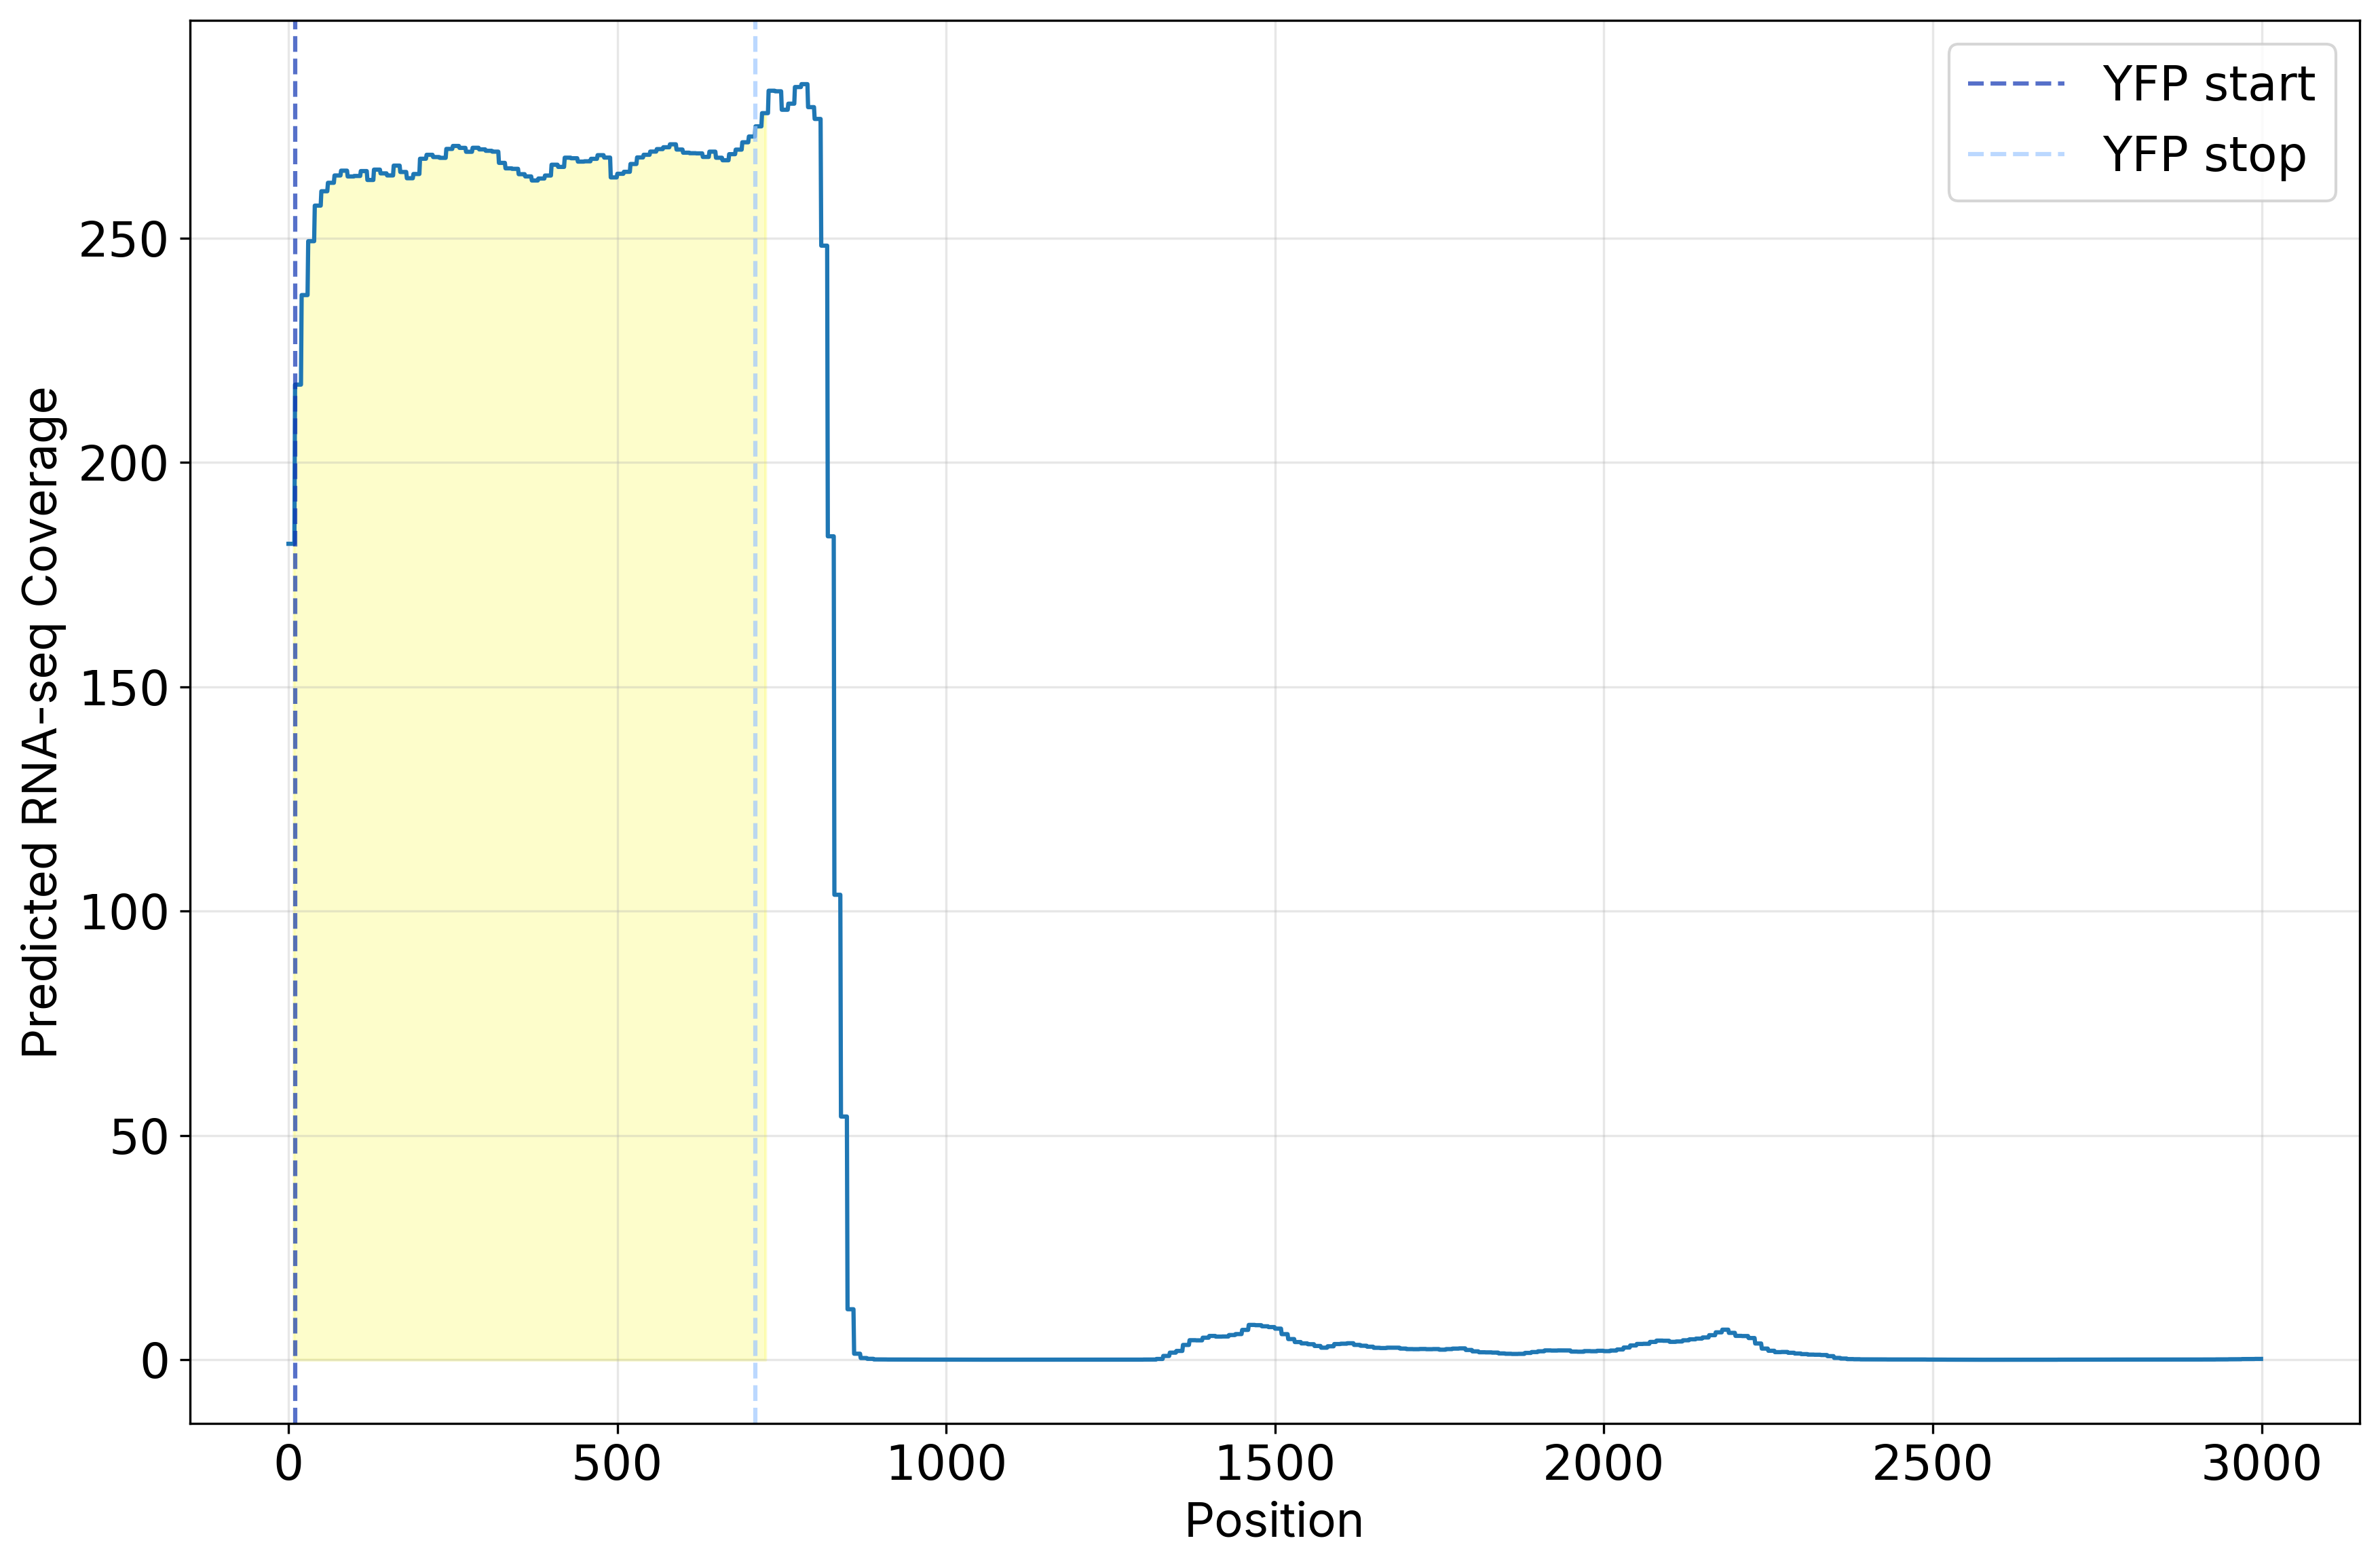

In [3]:
import matplotlib.pyplot as plt
from pypalettes import load_cmap
import numpy as np
from pyfonts import load_google_font

inter = load_google_font("Inter")
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = inter.get_name()
plt.rcParams["font.family"] = inter.get_name()
plt.rcParams["font.size"] = 17  # Set default font size
cmap = load_cmap("Acanthurus_leucosternon")

# Get the data for a single sample and track
track = 20
sample_idx = 38
sequence = batch[sample_idx].cpu().numpy()[track]  # shape: (length,)

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# Plot the line
ax.plot(range(len(sequence)), sequence)

# Add vertical lines for YFP start and stop using cmap colors
start_color = cmap(0.2)
stop_color = cmap(0.6)
ax.axvline(x=10, color=start_color, linestyle="--", alpha=0.7, label="YFP start")
ax.axvline(x=710, color=stop_color, linestyle="--", alpha=0.7, label="YFP stop")

# Fill the area between the vertical lines using cmap color
x = np.arange(len(sequence))
y = sequence
fill_color = cmap(0.8)
ax.fill_between(x, y, where=((x >= 8) & (x <= 8 + 717)), color=fill_color, alpha=0.3)

ax.set_xlabel("Position", font=inter, fontsize=17)
ax.set_ylabel("Predicted RNA-seq Coverage", font=inter, fontsize=17)
ax.tick_params(axis="both", which="major", labelsize=17)
ax.grid(True, alpha=0.3)
ax.legend(prop={"family": inter.get_name(), "size": 17})

plt.tight_layout()
plt.show()

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

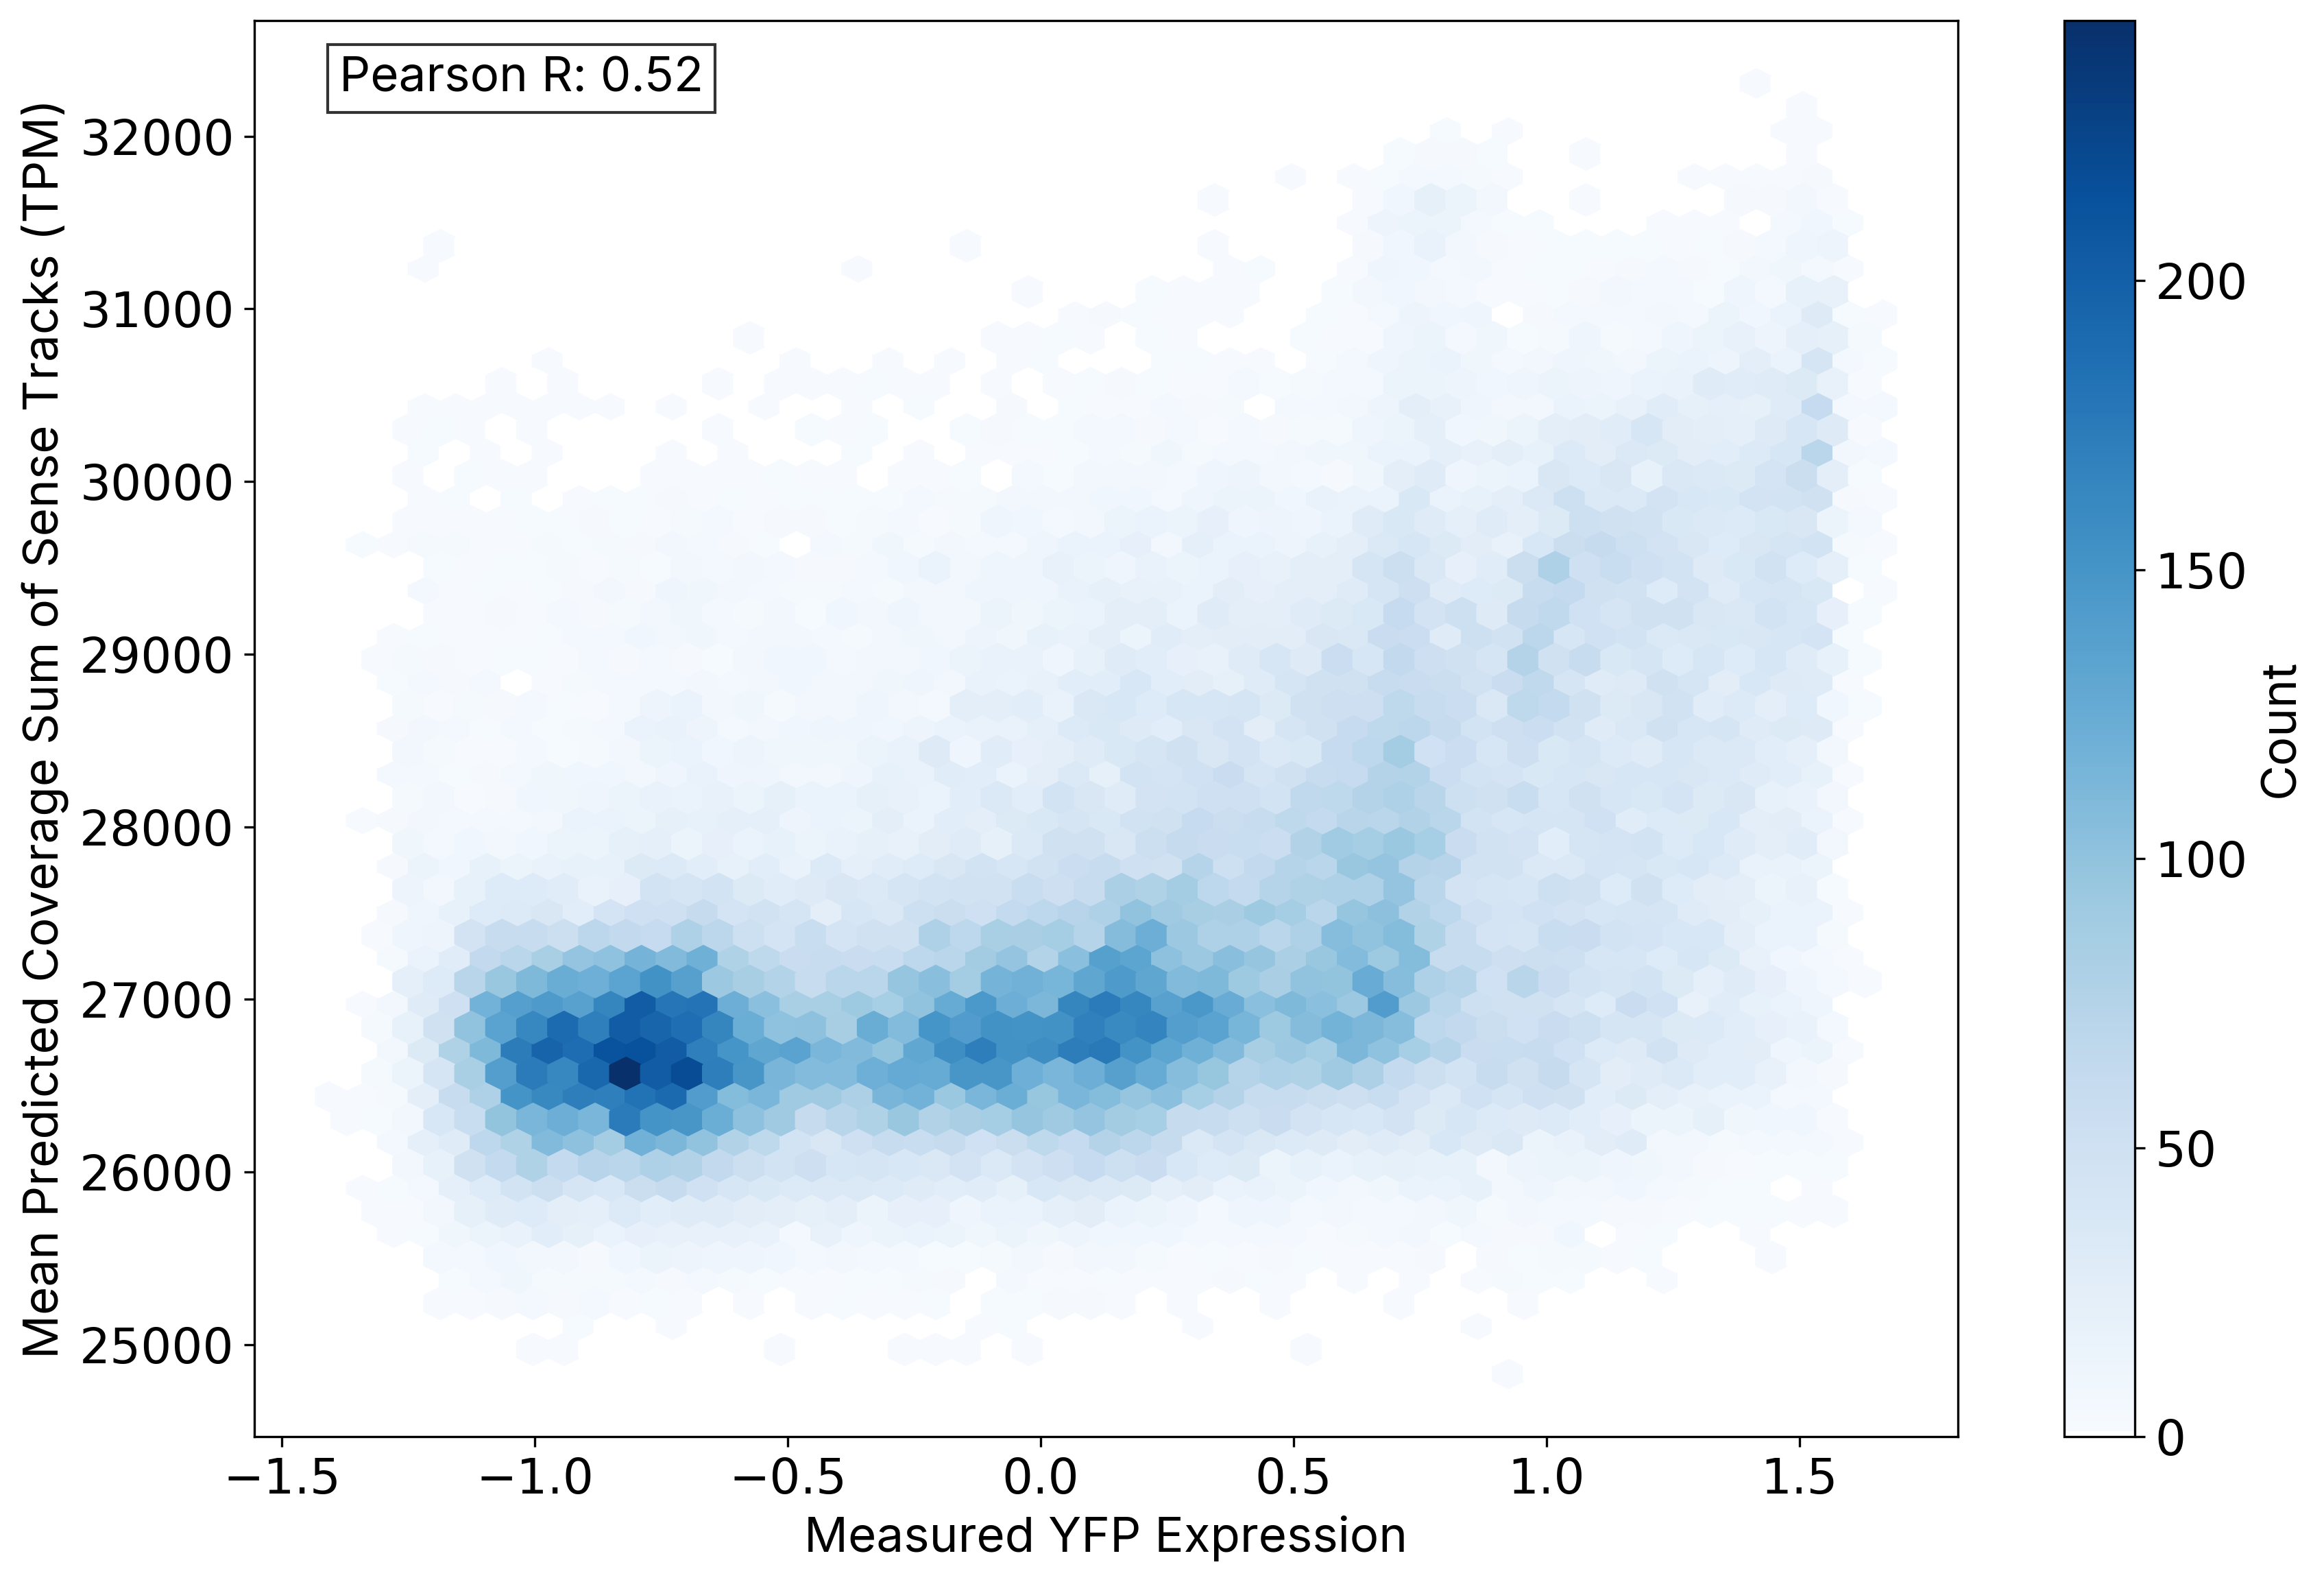

In [ ]:
## Eval of best DREAM challenge track

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

# Load Inter font
inter = load_google_font("Inter")
plt.rcParams["font.family"] = inter.get_name()
plt.rcParams["font.size"] = 17

df = pd.read_csv(f"{BEST_MODEL_FOLDER}/DREAM/all_samples_results.csv")

# Compute mean of tracks 0 through 80 (inclusive)
mean_tracks = df[[f"track_{i}" for i in range(81)]].mean(axis=1)

# Calculate Pearson correlation between expression and mean of tracks
corr, p_value = stats.pearsonr(df["expression_value"], mean_tracks)

# Create a custom colormap that starts with white for zero counts, then transitions to Blues
blues = plt.get_cmap("Blues")
colors = blues(np.linspace(0, 1, 256))
colors[0] = [1, 1, 1, 1]  # Set the first color (for 0 count) to white
white_blues = LinearSegmentedColormap.from_list("white_blues", colors)

# Create hexbin plot with specified dpi and font, using the custom colormap
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
hb = ax.hexbin(df["expression_value"], mean_tracks, gridsize=50, cmap=white_blues)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count", font=inter, fontsize=17)
ax.set_xlabel("Measured YFP Expression", font=inter, fontsize=17)
ax.set_ylabel(
    "Mean Predicted Coverage Sum of Sense Tracks (TPM)", font=inter, fontsize=17
)
ax.tick_params(axis="both", which="major", labelsize=17)

# Add correlation coefficient as text on plot
ax.text(
    0.05,
    0.95,
    f"Pearson R: {corr:.2f}",
    transform=ax.transAxes,
    font=inter,
    fontsize=17,
    bbox=dict(facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()


In [5]:
df

,sample_id,expression_value,track_0,track_1,track_2,track_3,track_4,track_5,track_6,track_7,...,track_152,track_153,track_154,track_155,track_156,track_157,track_158,track_159,track_160,track_161
0,sample_0,0.156331,4460.4230,4305.6094,4463.3237,4331.5215,4373.3820,4624.1074,4615.2197,4475.0320,...,959.74450,1011.13890,1092.5662,59.525414,1144.9613,60.353485,952.32610,5961.3438,909.96360,256.15530
1,sample_1,0.711710,3743.3428,3627.5903,3741.0664,3620.2040,3675.2852,3907.1711,3857.2622,3779.6052,...,976.33520,1024.23970,1125.4431,60.795230,1185.3536,66.146385,976.22010,5210.8125,922.96380,263.78540
2,sample_2,0.398692,3767.8953,3650.2705,3763.1416,3644.1104,3697.6782,3925.6868,3879.2932,3803.2393,...,975.12683,1022.43130,1125.5433,60.987404,1185.4172,66.162790,974.90100,5181.4062,922.13354,264.08472
3,sample_3,-0.489361,3837.6143,3715.6807,3833.4404,3713.4539,3765.3620,3993.5894,3951.3801,3869.7183,...,973.56140,1020.59740,1119.9453,61.072033,1177.7592,66.605090,971.62463,5241.1250,920.65590,263.44516
4,sample_4,0.702849,3988.6370,3858.9685,3984.3271,3862.5212,3912.0876,4144.0273,4109.5864,4017.1404,...,972.92755,1020.72314,1117.8829,60.790874,1174.8936,64.917170,970.37710,5386.0312,920.45776,262.62003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71098,sample_71098,1.649966,5245.8810,5044.7910,5227.5586,5100.9585,5126.9395,5332.0380,5357.9020,5239.2295,...,945.61230,994.53880,1084.5812,56.408176,1136.1726,51.413870,939.90454,6027.0312,895.44684,250.10312
71099,sample_71099,1.504799,4668.3440,4499.1090,4654.2505,4530.3906,4567.0825,4776.2085,4774.7285,4676.7676,...,953.65967,1002.70764,1105.0974,56.926334,1154.9321,52.172500,952.73865,5629.7500,907.41870,256.18155
71100,sample_71100,1.515044,4247.5790,4104.5635,4235.5250,4114.5570,4161.4766,4381.2266,4352.7520,4272.8060,...,958.68555,1008.84840,1118.4717,57.247704,1177.8420,52.345140,960.56665,5426.8125,911.99445,257.74540
71101,sample_71101,1.431438,4278.4336,4134.0190,4270.1445,4145.2344,4193.1846,4420.3030,4391.2910,4303.6040,...,953.15700,1004.48620,1113.1950,55.901940,1169.8234,48.481903,955.20010,5528.4375,907.65630,254.96431
